## (05PND)Assignment - Working with Pandas ##

In this assignment, you are given a csv file to analyze the tip data. Download the tips.csv file and store it in the same folder of your notebook file.  To complete this assignment, you goto each question and answer it in the code cell after it. You can add more code cell as necessary. Run your code after you finish the question to make sure there is no error before moving on to next question. Check your output with the output image provided in the question.

1. Download file PNDAssignmentTemplate.ipynb
1. Rename your file as PNDLastFirst.ipynb where Last is your last name and First is your first name
1. Download dataset tips.csv from this page. Make sure to save the csv file side by side with your notebook file.
1. Complete the following 15 questions.  When completing each questoin, run your code.  You may add extra code cell for your answer
1. Compare your result with the output image provided in the question
1. Submit your ipynb file and a screenshot of your repository showing that you have pushed the inpynb file to your repository**

**Q1. Import Numpy module as np and Pandas module as pd**

In [397]:
import numpy as np
import pandas as pd


**Q2. Load the tips.csv file into Pandas DataFrame object named tips_df, and display the first 5 rows.  See Output below:**

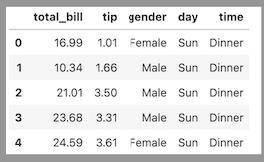

In [398]:
tips_df = pd.read_csv('Tips.csv')
tips_df.head()

,total_bill,tip,gender,day,time
0,16.99,1.01,Female,Sun,Dinner
1,10.34,1.66,Male,Sun,Dinner
2,21.01,3.50,Male,Sun,Dinner
3,23.68,3.31,Male,Sun,Dinner
4,24.59,3.61,Female,Sun,Dinner


**Q3. Display total row counts and column counts of tips_df. See Output below:**

(244, 5)

In [399]:
tips_df.shape

(244, 5)

**Q4. Add a calculated column named tip_percent; tip_percent is calculated using tip divided by total_bill.  See Output below:**

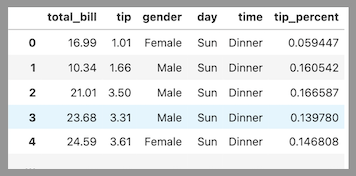

In [400]:
tips_df['tip_percent'] = tips_df['tip']/tips_df['total_bill']
tips_df.head()


,total_bill,tip,gender,day,time,tip_percent
0,16.99,1.01,Female,Sun,Dinner,0.059447
1,10.34,1.66,Male,Sun,Dinner,0.160542
2,21.01,3.50,Male,Sun,Dinner,0.166587
3,23.68,3.31,Male,Sun,Dinner,0.139780
4,24.59,3.61,Female,Sun,Dinner,0.146808


**Q5. Display total tips and bill amount by gender of the servers.  See Output below:**

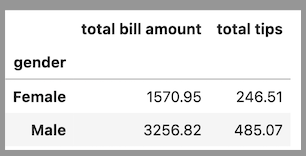

In [401]:
gender_totals = tips_df.groupby('gender')[['total_bill', 'tip']].sum()
gender_totals

,total_bill,tip
gender,,
Female,1570.95,246.51
Male,3256.82,485.07


**Q6. Count tips_df for tip_percent is 20% or more by day of the week.  See Output below:**

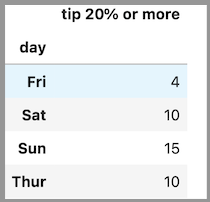

In [402]:
big_tips_by_day = tips_df[tips_df['tip_percent']>=0.2].groupby('day')['tip_percent'].count()
big_tips_by_day


day
Fri      4
Sat     10
Sun     15
Thur    10
Name: tip_percent, dtype: int64

**Q7. Display the average of tip by day of the week(column), gender of the servers(index) - using pivot table.  See Output below:**

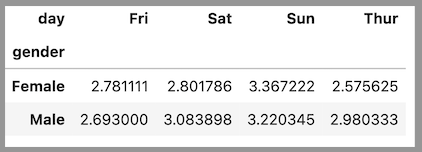

In [403]:
avg_tip_pivot = tips_df.pivot_table(values='tip',index='gender',columns='day', aggfunc='mean')
avg_tip_pivot

day,Fri,Sat,Sun,Thur
gender,,,,
Female,2.781111,2.801786,3.367222,2.575625
Male,2.693000,3.083898,3.220345,2.980333


**Q8. Display tips of more than 5 dollars at Sundays' dinners.  See Output below:**

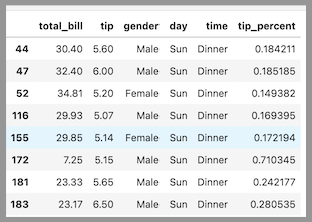

In [404]:

sunday_dinner_tips = tips_df[(tips_df['day'] == 'Sun') & 
                             (tips_df['time'] == 'Dinner') & 
                             (tips_df['tip'] > 5)]
sunday_dinner_tips

,total_bill,tip,gender,day,time,tip_percent
44,30.40,5.60,Male,Sun,Dinner,0.184211
47,32.40,6.00,Male,Sun,Dinner,0.185185
52,34.81,5.20,Female,Sun,Dinner,0.149382
116,29.93,5.07,Male,Sun,Dinner,0.169395
155,29.85,5.14,Female,Sun,Dinner,0.172194
172,7.25,5.15,Male,Sun,Dinner,0.710345
181,23.33,5.65,Male,Sun,Dinner,0.242177
183,23.17,6.50,Male,Sun,Dinner,0.280535


**Q9. Display count of each gender of servers by time and day of the week.  See Output below:**

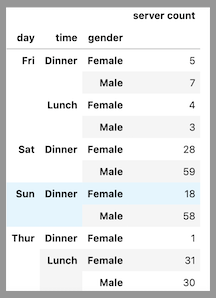

In [405]:
gender_counts = tips_df.groupby(['day', 'time', 'gender'])['gender'].count()
gender_counts

day   time    gender
Fri   Dinner  Female     5
              Male       7
      Lunch   Female     4
              Male       3
Sat   Dinner  Female    28
              Male      59
Sun   Dinner  Female    18
              Male      58
Thur  Dinner  Female     1
      Lunch   Female    31
              Male      30
Name: gender, dtype: int64

**Q10. Get a sample of 50 rows and save it to a new csv file named tips_samples.csv**

In [406]:
tips_sample = tips_df.sample(n=50)
tips_sample.to_csv('tips_samples.csv', index=False)
tips_sample.head()


,total_bill,tip,gender,day,time,tip_percent
139,13.16,2.75,Female,Thur,Lunch,0.208967
16,10.33,1.67,Female,Sun,Dinner,0.161665
39,31.27,5.00,Male,Sat,Dinner,0.159898
79,17.29,2.71,Male,Thur,Lunch,0.156738
2,21.01,3.50,Male,Sun,Dinner,0.166587


**The following 5 questions are working with groupby, merge and join. Here are the two DataFrame objects we will be using:**

In [407]:
import pandas as pd
invoice_df = pd.DataFrame({'invoice_no':[1001,1002,1003,1004,1005,1006,1007,1008,1009,1010],
                           'amount':[250.0, 321.0,115.5,623.5,500.0,435.0,345.0,875.0,53.6,700.5],
                           'customer':['Sonic','Blaze','Fearless','Dill','Urban','Lapton','Urban','JellySmith','Blaze','Fearless'],
                           'date':['2023-3-25','2022-5-3','2022-8-6','2022-11-15','2022-1-23','2023-7-10','2023-12-10','2023-2-5','2023-10-23','2022-3-16']
                          })
company_df = pd.DataFrame({'customer':['Sonic','Blaze','Beam','Stream','Fearless','Dill','BMC','Lapton','Urban','Synegy','JellySmith','Box','Jump','Savvy'],
                           'city': ['Houston','Austin','Chicago','Reno','Austin','Tucson','Los Angeles','Reno','Tucson','Houston','Austin','Atlanta','Miami','Atlanta']
                          })

**Q11. Merge company_df and invoice_df using inner join and display invoice sorting by city, customer and invoice date in ascending order.  See Output below:**

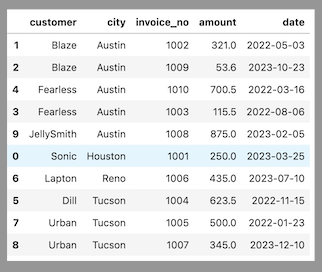

In [408]:
merged_df = company_df.merge(invoice_df, how='inner')
merged_df['date'] = pd.to_datetime(merged_df['date'])
sorted_df = merged_df.sort_values(by=['city', 'customer', 'date'], ascending=True)
sorted_df


,customer,city,invoice_no,amount,date
1,Blaze,Austin,1002,321.0,2022-05-03
2,Blaze,Austin,1009,53.6,2023-10-23
4,Fearless,Austin,1010,700.5,2022-03-16
3,Fearless,Austin,1003,115.5,2022-08-06
9,JellySmith,Austin,1008,875.0,2023-02-05
0,Sonic,Houston,1001,250.0,2023-03-25
6,Lapton,Reno,1006,435.0,2023-07-10
5,Dill,Tucson,1004,623.5,2022-11-15
7,Urban,Tucson,1005,500.0,2022-01-23
8,Urban,Tucson,1007,345.0,2023-12-10


**Q12. Display each customer with its total invoice count. See Output below:**

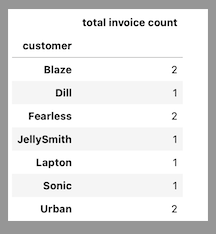

In [409]:
customer_invoice_counts = merged_df.groupby('customer')['invoice_no'].count()
customer_invoice_counts

customer
Blaze         2
Dill          1
Fearless      2
JellySmith    1
Lapton        1
Sonic         1
Urban         2
Name: invoice_no, dtype: int64

**Q13. Display total invoice amount by city and customer. See Output below:**

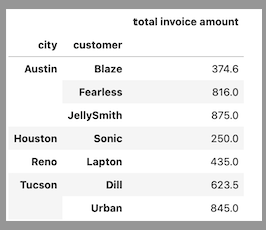

In [410]:
total_amounts = merged_df.groupby(['city', 'customer'])['amount'].sum()
total_amounts

city     customer  
Austin   Blaze         374.6
         Fearless      816.0
         JellySmith    875.0
Houston  Sonic         250.0
Reno     Lapton        435.0
Tucson   Dill          623.5
         Urban         845.0
Name: amount, dtype: float64

**Q14. Display customer that never places order before. See Output below:**

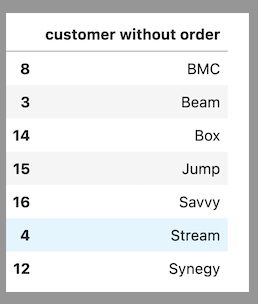

In [411]:
left_merged = company_df.merge(invoice_df, on='customer', how='left')
no_order_customers = left_merged[left_merged['invoice_no'].isna()]
no_order_customers[['customer']]

,customer
3,Beam
4,Stream
8,BMC
12,Synegy
14,Box
15,Jump
16,Savvy


**Q15. Display total invoice count and total invoice amount for each year (2022, 2023). See Output below:**

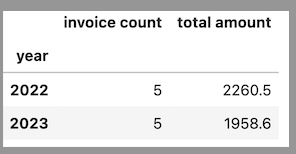

In [412]:
merged_df['year'] = merged_df['date'].dt.year
yearly_summary = merged_df.groupby('year').agg(
    total_invoice_count=('invoice_no', 'count'),
    total_invoice_amount=('amount', 'sum')
)
yearly_summary

,total_invoice_count,total_invoice_amount
year,,
2022,5,2260.5
2023,5,1958.6
